Group members (first and last names):

# Introduction
In today’s assignment, you will implement the Perceptron and work with the Hill-Climbing Optimizer 🧗

---
## How to pass the assignment?
Below, you will find the exercise questions. Each question that awards points is numbered and displays the available points in this format: **(0 pts)**.

### Answering Questions
- Provide your answers in the cell directly below each question.
- Use **Markdown** for text-based answers (in **English**).
- Use **code cells** for implementations.
- **Incomplete or incorrect answers receive 0 points.** Partial credit may be awarded at the teacher's discretion.
- Overly detailed answers do not grant extra points. Stick to what is asked.

### Critical Thinking Questions and Bonus Exercises
- Some questions are marked with a 🧠 (Critical Thinking) or a ⭐ (Bonus Exercise). These are for self-reflection and extra practice.
- They are **optional** and do **not** award any points.
- Answering them can help reinforce your understanding.

### Important Notes
- Save your work frequently! `(Ctrl + S)`
- Before submitting, `Restart Session and Run All` cells to ensure everything works correctly.
- **You need at least 26 points out of 39 (66%) to pass ✅**
---

# 1. Perceptron Fundamentals

#### 1.1 **(1pt) Write the equation of a Perceptron with $\LaTeX$.**

$f(x) := h(\langle w, x \rangle + b) = h(w \cdot x + b)$

#### 1.2 **(1pt) What is a *linearly separable dataset*, explained in simple terms?**

A linearly separable dataset is a dataset that can be split by a straight line visually (in 2D). In higher dimensions this would require the use of a hyperplane instead of a line but the concept is the same, a straight line or plane can split the two groups perfectly.

#### 1.3 **(3pts): Describe the Perceptron algorithm step-by-step. How does it work for linearly separable data?**

At first the Perceptron is like a "random" linear equation that will split the data arbitrarly. But that doesn't matter, because it will run (iterate) to train and optimize its equation. It does so by adjusting the weights and bias at each iteration. It will first compute the output of the model (almost random for the first one), then based on this ouput, we can calculate the error. This error is then used to update the weights and bias like so:

$w \leftarrow w + \eta(y_i - \widehat{y_i})x_i$

$b \leftarrow b + \eta(y_i - \widehat{y_i})$

In those equations, $\eta$ represents a step size, which we choose depending on wether we would like the model to adapt very quickly but may overshoot when close to the "answer", or wether we would prefer the model to go slowly and decrease the chances of overshooting. 

The new weights and bias are therefore computed by adding to the previous weights/bias values, the step size times the error (times the output for weights only). This way as the error is between -1 and 1 the adjustment will go in one direction or the other, depending on the error and over an infinite amount of time, it should stop oscillitating back and forth over the perfect optimization and get a perfect result.

---
# 2. Perceptron Implementation

In [105]:
# I'm importing some basic packages for you, but you'll have to import the rest :)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.datasets import load_iris 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split


sns.set(rc={'figure.figsize':(8,6)}, style="whitegrid")

#### 2.1 **(4pt) Write a Python class, `MyPerceptron` to implement a simple Perceptron model with the following methods:**

1. `__init__(self, dim, learning_rate=0.01, epochs=100)`:
This method should initialize the weights and bias. The bias term should be stored last in the weight array. It should also accept the learning rate and the number of epochs for training.

2. `predict(self, X)`:
This method should take an input vector `x` and return the predicted class label (1 or 0) based on the current weights and bias.

3. `train(self, X, y)`:
This method should train the model on the dataset `X` (features) and `y` (labels) using the Perceptron learning rule. It should update the weights and bias during training.

4. `score(self, X, y)`:
This method should compute and return the accuracy of the model by comparing its predictions on the input data `X` with the true labels `y`.

Make sure that your class is structured so that the bias term is stored last in the weight array, and the methods are named exactly as specified.

In [94]:
# Used ChatGPT to get some insights and learn some python tricks

class MyPerceptron:
    def __init__(self, dim, learning_rate=0.01, epochs=100):
        self.dim = dim
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = np.zeros(dim + 1)

    def predict(self, X):
        result = 0
        for index, x in enumerate(X):
            result += x * self.weights[index]
        result += self.weights[-1]
        result = 1 if result >= 0 else 0
        return (result)

    def train(self, X, y):
        for epoch in range(self.epochs):
            for index, x in enumerate(X):
                error = y[index] - self.predict(x)
                for i in range(len(self.weights) - 1):
                    self.weights += self.learning_rate * error * x[i]
                self.weights[-1] += self.learning_rate * error
        print("Successfully trained on dataset X")

    def score(self, X, y):
        predictions = [self.predict(x) for x in X]
        corrects = sum(1 for a, b in zip(predictions, y) if a == b)
        accuracy = corrects / len(y) * 100
        return (accuracy)
        

We can plot data points and a linear model $y = mx + q$, but how do we plot the decision boundary for $f(x) = \langle w, x \rangle + b$?  

We know that:  
- $f(x) > 0 $ represents one class (above the boundary)
- $ f(x) < 0 $ represents the other class (below the boundary)
- The decision boundary is at $ f(x) = 0 $

Rewriting this in terms of function coefficients:  
$$
f(x) = w_1 x + w_2 y + b = 0
$$
<br>
Solving for $y$:  
$$
y = \frac{-w_1}{w_2} x + \frac{-b}{w_2}
$$
<br>
So, the slope is $m = \frac{-w_1}{w_2}$ and the intercept is $q = \frac{-b}{w_2}$.

For now, use the functions below to compute and plot the boundary, but make sure you understand these steps.

In [95]:
def wb2mq(w, b):
    assert len(w) == 2, "Only works in 2D"
    # Handle case where w[1] or b is 0
    m = -w[0] / w[1] if w[1] != 0 else float('inf')  # Slope is infinite if w[1] is 0
    q = -b / w[1] if w[1] != 0 else float('inf') if w[0] != 0 else 0  # Handle b=0, w[1]=0 cases
    return [m, q]  # Compute m and q

def params2boundary(w, b, verbose=True):
    m, q = wb2mq(w, b)
    if verbose:
      print(f"m: {m}, q: {q}")
    return lambda x: m * x + q  # Return decision boundary function

If the code above makes sense, great! If not, review the math and the logic before moving forward—it'll only get trickier from here. Now, let's plot the decision boundary on top of our data.

#### 2.2 **(6pts) Train a Perceptron model to classify setosa vs the rest of the species in the Iris dataset using only the `sepal_length` and `petal_length` features, and visualize the decision boundary.**

1. Load the [Iris dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html#sklearn.datasets.load_iris) from `sklearn.datasets` and prepare the feature matrix `X` with `sepal_length` and `petal_length`.

 ❗The data from `sklearn.datasets` is **not** loaded as a pandas dataframe!
  You can find the feature names with `iris.feature_names`
2. Create a binary label vector `y`, where setosa is labeled as 0 and all other species are labeled as 1.
3. Instantiate and train a Perceptron model with the default parameters.
4. Print the trained weights and model accuracy.
5. Extract the weights and bias from the trained model.
6. Generate and plot the decision boundary using the weights and bias.

Expected Output:
1. The trained weights and accuracy of the Perceptron model.
2. A plot of the data points with the decision boundary line.

Example Output:
```
Trained Weights: [weight values and bias]
Accuracy: ??.??%

m: ?, q: ?
w: [? ? ], b: ?
```

Successfully trained on dataset X
Trained Weights: [0.02280501 0.02280501], 0.032805007003003886
Accuracy: 96.66666666666667
m: -1.0, q: -1.4385001942197508


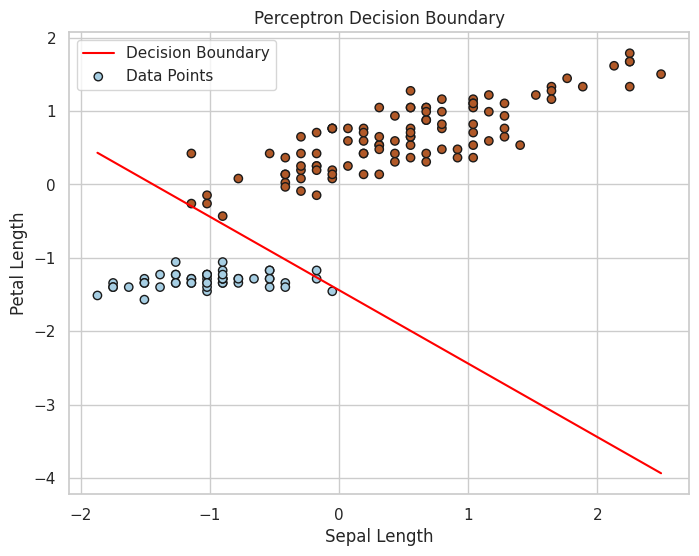

In [128]:
iris = load_iris()
scaler = StandardScaler()

X = iris.data[:, [0, 2]]
X = scaler.fit_transform(X)
y = iris.target
y = (y != 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

myPerceptron = MyPerceptron(2)
myPerceptron.train(X_train, y_train)
myWeights = myPerceptron.weights[:-1]
myBias = myPerceptron.weights[-1]
print(f"Trained Weights: {myWeights}, {myBias}")
print(f"Accuracy: {myPerceptron.score(X_test, y_test)}")

myBoundary = params2boundary(myWeights, myBias)

x_values = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
y_values = myBoundary(x_values)
plt.plot(x_values, y_values, label="Decision Boundary", color="red")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired, marker='o', edgecolors='k', label='Data Points')
plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.title('Perceptron Decision Boundary')

plt.legend()
plt.grid(True)
plt.show()

Alright! Let's do the same with the scikit-learn Perceptron.

#### 2.3 **(1pt) Train a scikit-learn [Perceptron](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html) on the same data as the last question.**
Note: it should take *no more than two lines*.

In [115]:
perceptron = Perceptron(max_iter=100, eta0=0.01, random_state=42)
perceptron.fit(X_train, y_train)

Perceptron(eta0=0.01, max_iter=100, random_state=42)

#### 2.4 **(1pt) Compare and visualize the decision boundaries of your implemented Perceptron and Sci-Kit Learn's Perceptron.**
- Plot the decision boundary for both your custom Perceptron implementation and Sci-Kit Learn’s Perceptron on the given dataset.
- Clearly label each decision boundary using `label='Perceptron'` in the plot function and calling `plt.legend()`.

To visualize the model's decision boundary, we first need to extract the weight vector $w$ and bias $b$ from a trained `scikit-learn` Perceptron. These are stored in:
- `coef_`: the weight coefficients ($w$)
- `intercept_`: the bias term ($b$, sometimes referred to as $q$)

💡 Be flexible with terminology—different libraries may use different names for the same concepts.

❗ Both `coef_` and `intercept_` are lists because scikit-learn's Perceptron is designed for multiclass classification, where multiple hyperplanes are needed to separate different classes. However, in binary classification, you only need one hyperplane. Make sure to access only the first element when extracting $w$ and $b$.

m: -1.0, q: -1.4385001942197508
m: 0.05015168604232029, q: -0.9551596448291552


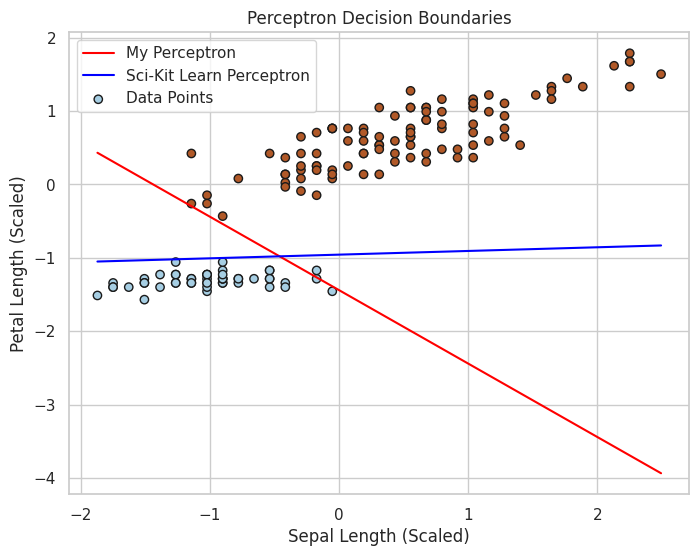

In [127]:
weights_sklearn = perceptron.coef_[0]
bias_sklearn = perceptron.intercept_[0]

def plot_decision_boundary(weights, bias, label, color, ax):
    decision_boundary = params2boundary(weights, bias)
    
    x_values = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
    y_values = decision_boundary(x_values)
    
    ax.plot(x_values, y_values, label=label, color=color)

fig, ax = plt.subplots(figsize=(8, 6))
plot_decision_boundary(myWeights, myBias, label='My Perceptron', color='red', ax=ax)
plot_decision_boundary(weights_sklearn, bias_sklearn, label='Sci-Kit Learn Perceptron', color='blue', ax=ax)
ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired, marker='o', edgecolors='k', label='Data Points')

ax.set_xlabel('Sepal Length (Scaled)')
ax.set_ylabel('Petal Length (Scaled)')
ax.set_title('Perceptron Decision Boundaries')
ax.legend()
ax.grid(True)
plt.show()

#### 2.5 **(1pt) Compare the resulting boundary against the one trained with your hand-made algorithm, and hypothesize why in your opinion they are similar/different.**

Appart from the starting weights and bias that may be different (mines are initiated at 0) I don't really know what could explain the difference as I made sure that the Perceptron from sci-kit learn used the same step-size and echops as mine. Therefore as they used the same data, they should get the same result with the same initial weigths and bias. That's why every time I run mine it gets the same result (mathematically it always does the same), but if I initiate the weights and bias to a random small value, then the decision boundary and accuracy differs everytime I run code.

So overall I think the scikit one probably has different starting value leading to a different final model.

---
# 3. The Effects of Learning Rate and Initialization

#### 3.1 **(3pts) Experiment with different learning rates and analyze their effect on perceptron convergence. How does the learning rate impact the model's ability to find a decision boundary? Explain your observations of at least 3 learning rates.**

This code trains a Perceptron on a synthetic binary classification dataset, saving the decision boundary after each step for a maximum of 10 iterations. It stops early if the same decision boundary is found three consecutive times, indicating convergence.

Use the buttons on the left of the plot to move through the steps.

❗ Only edit line 18

❗ You **do not** need to understand the interactive plotting code

In [ ]:
import plotly.graph_objects as go
from sklearn.linear_model import Perceptron
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler

# Generate a synthetic binary classification dataset
X, y = make_classification(n_samples=100, n_features=2, n_classes=2, n_redundant=0, n_clusters_per_class=1, class_sep=2, random_state=42)
y = np.where(y == 0, -1, 1)  # Convert labels to {-1, 1} for compatibility

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

##### EDIT HERE #####

# Define learning rate
learning_rate = ?

#####################

# Initialize perceptron
perceptron = Perceptron(eta0=learning_rate, random_state=42, fit_intercept=True, max_iter=1, warm_start=True)
perceptron.coef_ = np.ones((1, X.shape[1]))  # Initialize weights to ones
perceptron.intercept_ = np.ones(1)

# Store decision boundaries
boundaries = []
consecutive_converged = 0
prev_weights = None

# Initial decision boundary
w_init = perceptron.coef_[0]
b_init = perceptron.intercept_[0]
x_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
boundary_fn = params2boundary(w, b)
y_vals = boundary_fn(x_vals)
boundaries.append((x_vals, y_vals))

for i in range(10):  # Max iterations
    perceptron.partial_fit(X, y, classes=[-1, 1])
    w = perceptron.coef_[0]
    b = perceptron.intercept_[0]

    # Define decision boundary (w1*x1 + w2*x2 + b = 0)
    x_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
    boundary_fn = params2boundary(w, b, verbose=False)
    y_vals = boundary_fn(x_vals)
    boundaries.append((x_vals, y_vals))

    # Check convergence
    if prev_weights is not None and np.allclose(prev_weights, w):
        consecutive_converged += 1
    else:
        consecutive_converged = 0
    prev_weights = w.copy()

    if consecutive_converged >= 2:
        break

# Create interactive plot with buttons
fig = go.Figure()
fig.update_layout(width=1300, height=500)
for i, (x_vals, y_vals) in enumerate(boundaries):
    fig.add_trace(go.Scatter(x=x_vals, y=y_vals, mode='lines', name=f'Step {i}', visible=(i == 0)))

# Plot data points
fig.add_trace(go.Scatter(x=X[y == 1][:, 0], y=X[y == 1][:, 1], mode='markers', name='Class 1', marker=dict(color='blue')))
fig.add_trace(go.Scatter(x=X[y == -1][:, 0], y=X[y == -1][:, 1], mode='markers', name='Class -1', marker=dict(color='orange')))

# Add buttons to step through iterations
steps = []
for i in range(len(boundaries)):
    if i == 0:
      step = dict(
          label=f"Init",
          method='update',
          args=[{'visible': [False] * len(fig.data)}]
      )
    else:
      step = dict(
          label=f"Step {i}",
          method='update',
          args=[{'visible': [False] * len(fig.data)}]
      )
    step['args'][0]['visible'][i] = True  # Show only the selected step
    step['args'][0]['visible'][-2:] = [True, True]  # Keep data points visible
    steps.append(step)

fig.update_layout(
    updatemenus=[
        dict(
            type='buttons',
            showactive=True,
            buttons=steps
        )
    ],
    title=f'Effect of Learning Rate on Perceptron Convergence - Learning Rate: {learning_rate}',
    showlegend=True
)

fig.show()

#### 3.2 **(1pt) Why is the Perceptron’s weight update rule considered discontinuous (updates with sudden jumps)? How does this affect the movement of the decision boundary during training?**

#### 3.3 **(2pts) Loop through 3 random states for the `scikit-learn` perceptron and plot the decision boundaries over the given data. Comment on the effect of the initialization on non-linearly separable data.**

In [ ]:
from sklearn.datasets import make_circles

# Generate a non-linearly separable dataset
X, y = make_circles(n_samples=100, noise=0.1, factor=0.4, random_state=42)
# Plot the data points
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='coolwarm', edgecolor='k')

# Plot decision boundaries for 3 different random states


# Axis labels and title
plt.title('Perceptron Decision Boundaries for Different Random States')
plt.legend()
plt.show()


---
# 4. Hill-Climbing Optimiser


#### 4.1 **(3pt) Explain how the Hill-Climbing Optimiser works step-by-step.**

## Hill-Climbing Interactive Demo
Run the following code a few times to see what steps the optimizer takes. Use the buttons on the left of the plot to move through the steps.

In [ ]:
# DO NOT EDIT THIS CELL :)
import numpy as np
import plotly.graph_objects as go

# Define function
def f(x):
    return np.sin(6 * x) + x**2 * np.cos(x**2)

# Hill Climbing Algorithm
x = np.random.uniform(-1.75, 1.75)  # Random starting point
max_step_size = 0.3
max_iters = 15

steps = [x]
for _ in range(max_iters):
    new_x = x + np.random.uniform(-max_step_size, max_step_size)
    if f(new_x) > f(x):  # Accept only if function value increases
        x = new_x
        steps.append(x)

# Generate function values for plotting
x_vals = np.linspace(-2, 2, 400)
y_vals = f(x_vals)

# Create figure
fig = go.Figure()
fig.update_layout(width=1300, height=500)
fig.add_trace(go.Scatter(x=x_vals, y=y_vals, mode="lines", name="Function"))
optimizer_point = go.Scatter(x=[steps[0]], y=[f(steps[0])], mode="markers", marker=dict(size=10, color="red"), name="Optimizer Step")
fig.add_trace(optimizer_point)

# Buttons to step through optimization
buttons = []
for i in range(len(steps)):
    buttons.append(dict(
        label=f"Step {i+1}",
        method="update",
        args=[{"x": [x_vals, [steps[i]]], "y": [y_vals, [f(steps[i])]]}]
    ))

fig.update_layout(
    updatemenus=[dict(type="buttons", showactive=True, buttons=buttons)],
    title="Hill Climbing Steps",
    xaxis_title="x",
    yaxis_title="f(x)"
)

fig.show()


#### 4.2 **(4pts) Use `scipy`'s optimize method with the [downhill simplex algorithm](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.fmin.html#scipy.optimize.fmin) (`fmin`). Comment your findings in one sentence.**

- Initialise the starting point at -225.
- Plot the starting (green) and end (red) points of the optimizer.
- Use `matplotlib` and label all axes and give the plot a title.

In [ ]:
# Define a wild function with multiple local minima
def f(x):
    return (x % 521) * np.sin(x / 47) * np.exp(-0.002 * x)

# Define the starting point and optimizer



# Generate data
x_vals = np.linspace(-1000, 0, 1001)
y_vals = f(x_vals)

# Plot the data
plt.figure(figsize=(10, 6))
plt.grid()
plt.plot(x_vals, y_vals)

# Plot the initial and end points



# Label plots
plt.title('Hill-Climbing Descent')
plt.xlabel('x')
plt.ylabel('f(x)');


#### 4.3 **(1pt) Repeat with a starting point of -550. Plot and comment on your findings in one sentence.**

In [ ]:
# Define the starting point and optimizer



# Plot the data
plt.figure(figsize=(10, 6))
plt.grid()
plt.plot(x_vals, y_vals)

# Plot the initial and end points



# Label plots
plt.title('Hill-Climbing Descent')
plt.xlabel('x')
plt.ylabel('f(x)');


#### 4.4 **(2pts) Repeat with a starting point at -775 and a maximum of 2 iterations. Plot and comment your findings in one sentence.**

In [ ]:
# Define the starting point and optimizer



# Plot the data
plt.figure(figsize=(10, 6))
plt.grid()
plt.plot(x_vals, y_vals)

# Plot the initial and end points



# Label plots
plt.title('Hill-Climbing Descent')
plt.xlabel('x')
plt.ylabel('f(x)');


#### 4.5 **(pts) Run the `scipy` optimiser 100 times with random initialization points and print the number of times the optimiser finds the global minimum.**

❗To hide the output of the `optimize.fmin` method, pass `disp=False` as a parameter.

Expected Output:
```
After x random initializations, the algorithm found the global minimum x times
```

**Congratulations on completing this assignment!** 🎉  

Through this exercise, you built a strong foundation in perceptron learning by implementing your own model and comparing it with Sci-Kit Learn’s version. You explored the impact of learning rates and weight initialization, gaining insight into how these factors influence training. Additionally, you experimented with the Hill-Climbing optimizer, broadening your understanding of optimization techniques in machine learning.  

I hope you're also getting more and more comfortable with **Pandas, NumPy, Seaborn, and Matplotlib**. The more you use these libraries, the more automatic it will feel—you'll start remembering how to do things without constantly checking the documentation. That said, looking things up is completely normal! Just make sure to **type out the code yourself** instead of copy-pasting. This helps build muscle memory, making coding feel more natural over time.  

Great work, and happy coding! 🚀💻